In [1]:
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from pgs_tools import make_gaussian_fields, make_lithotype_map, plot_fields, plot_lithotype_map
from ca_tools import get_neighbours, decide_new_state, run_ca, plot_ca_evolution




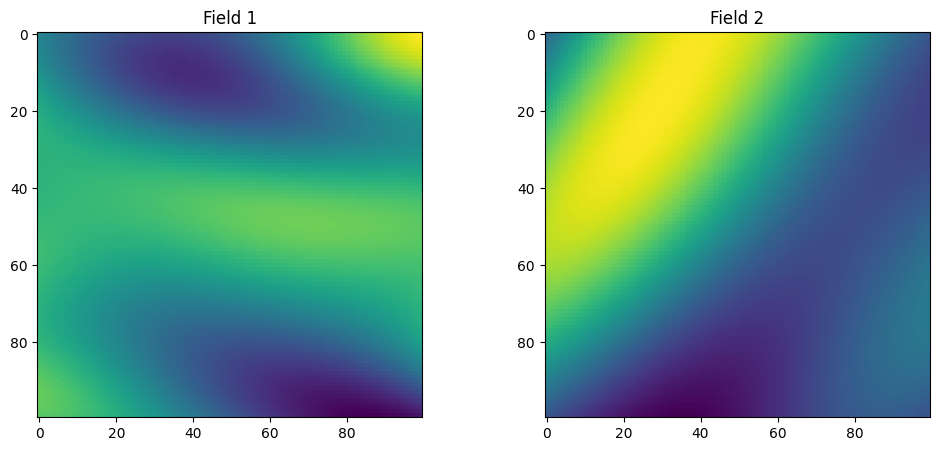

In [2]:
field_1_2d, field_2_2d = make_gaussian_fields(
    grid_size=100,
    len_scale_1=[25, 50], angles_1=[0, 0], seed_1=1,
    len_scale_2=[50, 100], angles_2=[np.pi/4, np.pi/4], seed_2=2
)


plot_fields(field_1_2d, field_2_2d, cmap='viridis', figsize=(12, 5))


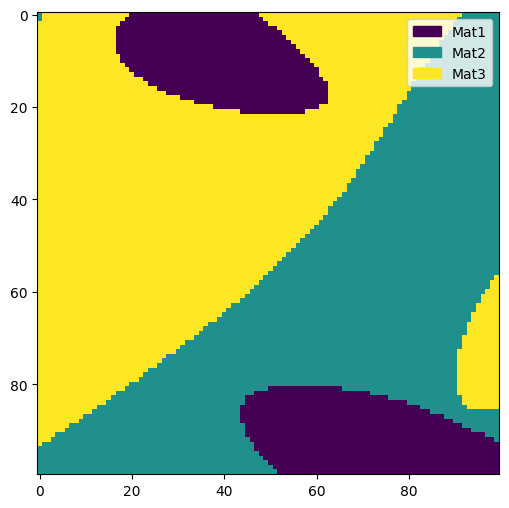

In [3]:
from pgs_tools import make_lithotype_map, plot_lithotype_map

lithotype_map = make_lithotype_map(field_1_2d, field_2_2d, Mat1=0.20, Mat2=0.50, Mat3=0.30)

plot_lithotype_map(lithotype_map, cmap='viridis')

In [4]:

lithotype_map, snapshots = run_ca(lithotype_map,
       generations=10,
       threshold=1,
       checkpoints = list(range(1, 11))
)
      

Generation 1:
  Rock type 0: 16.5%
  Rock type 1: 39.3%
  Rock type 2: 44.2%
Generation 2:
  Rock type 0: 17.0%
  Rock type 1: 40.0%
  Rock type 2: 43.0%
Generation 3:
  Rock type 0: 17.3%
  Rock type 1: 40.7%
  Rock type 2: 41.9%
Generation 4:
  Rock type 0: 17.7%
  Rock type 1: 41.5%
  Rock type 2: 40.8%
Generation 5:
  Rock type 0: 18.0%
  Rock type 1: 42.3%
  Rock type 2: 39.7%
Generation 6:
  Rock type 0: 18.3%
  Rock type 1: 43.0%
  Rock type 2: 38.6%
Generation 7:
  Rock type 0: 18.6%
  Rock type 1: 43.8%
  Rock type 2: 37.6%
Generation 8:
  Rock type 0: 18.8%
  Rock type 1: 44.6%
  Rock type 2: 36.6%
Generation 9:
  Rock type 0: 19.0%
  Rock type 1: 45.4%
  Rock type 2: 35.6%
Generation 10:
  Rock type 0: 19.1%
  Rock type 1: 46.2%
  Rock type 2: 34.6%


In [5]:
plot_ca_evolution(snapshots, interval=500, cmap='viridis', figsize=(12, 5))

In [6]:
from ca_tools import get_neighbours

test_grid = np.array([
    [0, 1, 2],
    [1, 1, 0],
    [2, 0, 1]
])



print(get_neighbours(test_grid, 1, 1))                          # should be unchanged: [1, 0, 1, 0]
print(get_neighbours(test_grid, 1, 1, neighbourhood='moore'))   # should add the 4 diagonals

([np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1])
([np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(1)], [1, 1, 1, 1, 1, 1, 1, 1])


In [7]:
print(sorted(get_neighbours(test_grid, 1, 1)))                         # expect [0, 0, 1, 1]
print(sorted(get_neighbours(test_grid, 1, 1, neighbourhood='moore')))  # expect [0, 0, 0, 1, 1, 1, 2, 2]


big_grid = np.arange(25).reshape(5, 5) % 3
print(len(get_neighbours(big_grid, 2, 2, neighbourhood='von_neumann', radius=2)))  # expect 12
print(len(get_neighbours(big_grid, 2, 2, neighbourhood='moore', radius=2)))        # expect 24

[[np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1]]
[[np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(1)], [1, 1, 1, 1, 1, 1, 1, 1]]
2
2


In [8]:
print(sorted(get_neighbours(test_grid, 1, 1)))                         # expect [0, 0, 1, 1]
print(len(get_neighbours(big_grid, 2, 2, neighbourhood='von_neumann', radius=2)))  # expect 12

print(sorted(get_neighbours(test_grid, 0, 0, boundary='periodic')))  # expect [1, 1, 2, 2]

[[np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1]]
2
[[1, 1, 1, 1], [np.int64(2), np.int64(2), np.int64(1), np.int64(1)]]


In [9]:
print(sorted(get_neighbours(test_grid, 1, 1)))  # expect [0, 0, 1, 1]

print(sorted(get_neighbours(test_grid, 1, 0, boundary='reflective')))  # expect [0, 1, 1, 2]

[[np.int64(1), np.int64(1), np.int64(0), np.int64(0)], [1, 1, 1, 1]]
[[np.int64(0), np.int64(1), np.int64(1), np.int64(2)], [1, 1, 1, 1]]


In [10]:
values, weights_out = get_neighbours(test_grid, 1, 1)
print(sorted(values))  # expect [0, 0, 1, 1] - regression check, unweighted defaults

values, weights_out = get_neighbours(test_grid, 1, 1, neighbourhood='moore', direct_weight=2, diagonal_weight=1)
print(list(zip(values, weights_out)))  # direct neighbours should show weight 2, diagonals weight 1

[np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
[(np.int64(0), 1), (np.int64(1), 2), (np.int64(2), 1), (np.int64(1), 2), (np.int64(0), 2), (np.int64(2), 1), (np.int64(0), 2), (np.int64(1), 1)]


In [11]:
print(decide_new_state([1, 1, 1, 0], current_state=0, threshold=1))  # expect 1 (majority of 3 beats threshold)
print(decide_new_state([1, 1, 0, 0], current_state=0, threshold=2))  # expect 0 (tied 2-2, doesn't clear threshold, stays put)

1
0
